# Noisy-LJ history-conditioned latent rollout


In [1]:
%matplotlib inline
import os, sys
from pathlib import Path
os.environ.setdefault('MPLCONFIGDIR', '/tmp/matplotlib')
PROJECT_ROOT = Path.cwd().resolve()
while PROJECT_ROOT != PROJECT_ROOT.parent and not (PROJECT_ROOT/'src'/'lss').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT/'src') not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT/'src'))
import matplotlib.pyplot as plt
import optuna
import numpy as np
import pandas as pd
import torch
import importlib
import lss.latent.experiment as _latent_experiment
importlib.reload(_latent_experiment)
from lss.latent.experiment import evaluate_autoencoder_reconstruction_horizons, run_latent_experiment, seed_everything
from lss.latent.training import (calc_rollout_p_ratio_by_method, decode_latent_to_graph,
                                 encode_frame_latent, encode_reference_context,
                                 encode_transition_batch, latent_step)
from lss.latent.simulation import r2_score
from lss.plotting import PAPER_COLORS, apply_editorial_style, dataset_color, style_axes
from lss.utils import resolve_device
apply_editorial_style()
DEVICE = resolve_device('auto')
DEVICE


/home/alexz/Documents/course_project/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


'cuda'

## Configuration


In [2]:
SEED = 234
TRAIN_TRAJECTORIES = 30
VAL_TRAJECTORIES = 30
TRAIN_STEPS_PER_SIM = 200
MAX_EPOCHS = 30
PATIENCE = 4
AE_HPO_TRIALS = 12
AE_HPO_MAX_EPOCHS = 24
FORCE_TRAIN_PROPAGATOR = True
FORCE_TRAIN_AE = True
AE_TRAIN_TRAJECTORIES = {
    'reid': 30,
    'lj_noisy': TRAIN_TRAJECTORIES,
}

LJ_SOURCE = 'lj_noisy'
LJ_PATH = PROJECT_ROOT/'data'/'lj-noisy-eps0.01-sigma1.0-cutoff1.122_200sims_200frames.pt'
OUTPUT = PROJECT_ROOT/'notebooks'/'results'/'06d_noisy_lj_history_rollout'
OUTPUT.mkdir(parents=True, exist_ok=True)
AE_CACHE = OUTPUT/'06d_reid_noisy_lj_shared_ae.pt'
assert LJ_PATH.is_file(), LJ_PATH

# Both the frozen AE and the propagator train on Reid and noisy LJ.
DATASETS = {
    'reid': ('Reid', PROJECT_ROOT/'data'/'reid_200_frames.pt'),
    LJ_SOURCE: ('noisy LJ', LJ_PATH),
}
for _, path in DATASETS.values(): assert path.is_file(), path
EXPERIMENTS = {'reid_noisy_lj_history_truncated_5': {'model': 'history_mlp'}}
print({'device': str(DEVICE), 'ae_cache': str(AE_CACHE), 'force_train_ae': FORCE_TRAIN_AE, 'force_train_propagator': FORCE_TRAIN_PROPAGATOR, 'propagator_sources': tuple(DATASETS), 'experiments': EXPERIMENTS})


{'device': 'cuda', 'ae_cache': '/home/alexz/Documents/course_project/notebooks/results/06d_noisy_lj_history_rollout/06d_reid_noisy_lj_shared_ae.pt', 'force_train_ae': True, 'force_train_propagator': True, 'propagator_sources': ('reid', 'lj_noisy'), 'experiments': {'reid_noisy_lj_history_truncated_5': {'model': 'history_mlp'}}}


## Frozen autoencoder; noisy-LJ history propagator


In [3]:
mixture = [
    {'name': key, 'label': label, 'path': str(path),
     'train_count': AE_TRAIN_TRAJECTORIES[key], 'val_count': VAL_TRAJECTORIES}
    for key, (label, path) in DATASETS.items()
]
ae_config = {
    'latent_dim': 2, 'latent_tokens': 32, 'hidden_size': 64, 'model': 'attention',
    'edge_feature_dim': 4, 'target_mode': 'normalized_delta', 'node_feature_mode': 'normalized_delta',
    'max_train_frames_per_sim': TRAIN_STEPS_PER_SIM + 1, 'val_frame_skip': 1,
    'max_val_frames_per_sim': TRAIN_STEPS_PER_SIM + 1,
    'max_epochs': 30, 'patience': 4, 'lr': 1e-4, 'weight_decay': 1e-5,
    'balance_sources': False, 'mix_sources': True,
    'pratio_eval_every': 2, 'pratio_eval_steps': [10, 50, 100],
    'checkpoint_metric': 'val_ae_mean_source_p_ratio_r2_step_100', 'checkpoint_mode': 'max',
}

# Small shared-AE search.  Every trial uses the identical Reid/noisy-LJ split;
# its objective is the equally weighted mean of their held-out step-100 p-ratio R² values.
AE_HPO_OUTPUT = OUTPUT/'ae_optuna'
AE_HPO_OUTPUT.mkdir(exist_ok=True)

def ae_hpo_objective(trial):
    trial_ae_config = {
        **ae_config,
        'latent_dim': trial.suggest_categorical('latent_dim', [2, 4, 6, 8]),
        'latent_tokens': trial.suggest_categorical('latent_tokens', [16, 32, 48]),
        'hidden_size': trial.suggest_categorical('hidden_size', [48, 64, 96, 128]),
        'lr': trial.suggest_float('lr', 3e-5, 3e-4, log=True),
        'weight_decay': trial.suggest_float('weight_decay', 1e-6, 1e-4, log=True),
        'max_epochs': AE_HPO_MAX_EPOCHS, 'patience': PATIENCE,
        'pratio_eval_every': 2, 'pratio_eval_steps': [100],
    }
    trial_source = {
        'dataset_name': '06d_reid_noisy_lj_ae_hpo', 'source_name': '06d AE Optuna',
        'label': '06d Reid + noisy-LJ AE Optuna', 'path': str(LJ_PATH), 'dataset_mixture': mixture,
    }
    trial_cache = AE_HPO_OUTPUT/f'trial_{trial.number:03d}.pt'
    trial_config = {
        'ae_config': trial_ae_config, 'dataset_name': trial_source['dataset_name'],
        'split_seed': SEED, 'split_stratify_temperature': False, 'model_seed': SEED,
        'device': str(DEVICE), 'pos_dim': 2, 'batch_graphs': 32, 'frame_skip': 1,
        'train_frame_start_order': 0, 'coordinate_normalization': 'position_normalization',
        'edge_mode': 'compact_stored', 'should_rollout': False,
        'should_train_propagator': False, 'early_stop_min_delta': 1e-5,
        'force_train': True, 'force_train_autoencoder': True,
        'cache_path': str(trial_cache), 'cache_require_matching_config': True,
    }
    seed_everything(SEED)
    trial_result = run_latent_experiment(trial_source, trial_config, device=DEVICE)
    score_column = 'val_ae_mean_source_p_ratio_r2_step_100'
    scores = trial_result['ae_history'][['epoch', score_column]].dropna()
    if scores.empty:
        raise optuna.TrialPruned('No finite source-balanced step-100 R².')
    best_row = scores.loc[scores[score_column].idxmax()]
    trial.set_user_attr('best_epoch', int(best_row.epoch))
    trial.set_user_attr('ae_settings', {
        key: trial_ae_config[key]
        for key in ('latent_dim', 'latent_tokens', 'hidden_size', 'lr', 'weight_decay')
    })
    return float(best_row[score_column])

study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=SEED))
study.optimize(ae_hpo_objective, n_trials=AE_HPO_TRIALS)
best_ae_settings = study.best_trial.user_attrs['ae_settings']
ae_config.update(best_ae_settings)
hpo_summary = study.trials_dataframe(attrs=('number', 'value', 'params', 'user_attrs')).sort_values('value', ascending=False)
display(hpo_summary.head(10).round(4))
print({'best_combined_step100_r2': study.best_value, 'best_epoch': study.best_trial.user_attrs['best_epoch'], **best_ae_settings})
source = {
    'dataset_name': 'reid_noisy_lj_history_truncated_5',
    'source_name': 'frozen 06d AE / Reid + noisy-LJ three-frame history propagator',
    'label': 'frozen 06d AE, Reid + noisy-LJ three-frame history propagator',
    'path': str(LJ_PATH), 'dataset_mixture': mixture,
}

# Shared AE recipe with configurable source-wise training counts.
ae_mixture = [
    {'name': key, 'label': label, 'path': str(path), 'train_count': AE_TRAIN_TRAJECTORIES[key], 'val_count': VAL_TRAJECTORIES}
    for key, (label, path) in DATASETS.items()
]
ae_source = {
    'dataset_name': 'reid_noisy_lj_shared', 'source_name': '06d Reid + noisy-LJ shared AE',
    'label': '06d Reid + noisy-LJ shared AE', 'path': str(LJ_PATH), 'dataset_mixture': ae_mixture,
}
ae_training_config = {
    'ae_config': ae_config, 'dataset_name': ae_source['dataset_name'], 'split_seed': SEED,
    'split_stratify_temperature': False, 'model_seed': SEED, 'device': str(DEVICE),
    'pos_dim': 2, 'batch_graphs': 32, 'frame_skip': 1, 'train_frame_start_order': 0,
    'coordinate_normalization': 'position_normalization', 'edge_mode': 'compact_stored',
    'should_rollout': False, 'should_train_propagator': False, 'early_stop_min_delta': 1e-5,
    'force_train': FORCE_TRAIN_AE, 'force_train_autoencoder': True,
    'cache_path': str(AE_CACHE), 'cache_require_matching_config': True,
}
seed_everything(SEED)
ae_training_result = run_latent_experiment(ae_source, ae_training_config, device=DEVICE)

ae_r2_columns = {source_key: f'val_ae_source_{source_key}_p_ratio_r2_step_100' for source_key in DATASETS}
ae_loss_columns = {source_key: f'val_ae_source_{source_key}_position_mse_step_100' for source_key in DATASETS}
ae_sum_columns = {source_key: f'val_ae_source_{source_key}_p_ratio_r2_sum_10_50_100' for source_key in DATASETS}
ae_min_sum_column = 'val_ae_min_source_p_ratio_r2_sum_10_50_100'
fig, axes = plt.subplots(1, 3, figsize=(17.0, 4.0), constrained_layout=True)
for source_key, label in DATASETS.items():
    color = dataset_color(source_key)
    r2_rows = ae_training_result['ae_history'].reindex(columns=['epoch', ae_r2_columns[source_key]]).dropna()
    loss_rows = ae_training_result['ae_history'].reindex(columns=['epoch', ae_loss_columns[source_key]]).dropna()
    if not r2_rows.empty:
        axes[0].plot(r2_rows.epoch, r2_rows[ae_r2_columns[source_key]], marker='o', markersize=3.8, linewidth=1.7, color=color, label=label[0])
    if not loss_rows.empty:
        axes[1].plot(loss_rows.epoch, loss_rows[ae_loss_columns[source_key]], marker='o', markersize=3.8, linewidth=1.7, color=color, label=label[0])
    sum_rows = ae_training_result['ae_history'].reindex(columns=['epoch', ae_sum_columns[source_key]]).dropna()
    if not sum_rows.empty:
        axes[2].plot(sum_rows.epoch, sum_rows[ae_sum_columns[source_key]], marker='o', markersize=3.8, linewidth=1.7, color=color, label=label[0])
min_sum_rows = ae_training_result['ae_history'].reindex(columns=['epoch', ae_min_sum_column]).dropna()
if not min_sum_rows.empty:
    axes[2].plot(min_sum_rows.epoch, min_sum_rows[ae_min_sum_column], color=PAPER_COLORS['ink'], ls='--', lw=1.3, label='minimum source sum')
axes[0].axhline(0, color=PAPER_COLORS['slate'], lw=.8)
axes[0].set_ylim(bottom=0)
style_axes(axes[0], xlabel='AE epoch', ylabel='validation AE p-ratio $R^2$ at step 100', legend=True)
style_axes(axes[1], xlabel='AE epoch', ylabel='validation reconstruction position MSE at step 100', legend=True)
style_axes(axes[2], xlabel='AE epoch', ylabel='validation p-ratio $R^2$ sum at steps 10, 50, 100', legend=True)
plt.show()

ae_pratio_rows, _ = evaluate_autoencoder_reconstruction_horizons(
    ae_training_result['ae'], ae_training_result['val_data'], cfg=ae_training_result['params'],
    normalizers=ae_training_result['normalizers'], dataset=ae_training_result['label'],
    split_name='val', rollout_steps=[100], device=DEVICE,
)
lj_pratio_rows = ae_pratio_rows.query("source == 'lj_noisy' and rollout_steps == 100").dropna(subset=['true_p_ratio', 'pred_p_ratio'])
fig, ax = plt.subplots(figsize=(4.6, 4.2), constrained_layout=True)
ax.scatter(lj_pratio_rows.true_p_ratio, lj_pratio_rows.pred_p_ratio, s=28, alpha=.78, color=dataset_color(LJ_SOURCE), edgecolor='none')
limits = lj_pratio_rows[['true_p_ratio', 'pred_p_ratio']].to_numpy(float).ravel()
limits = limits[np.isfinite(limits)]
if len(limits):
    lo, hi = limits.min(), limits.max()
    pad = .05 * max(hi - lo, 1e-6)
    ax.plot([lo - pad, hi + pad], [lo - pad, hi + pad], '--', color=PAPER_COLORS['ink'], lw=1.0)
    ax.set_xlim(lo - pad, hi + pad)
    ax.set_ylim(lo - pad, hi + pad)
lj_r2 = r2_score(lj_pratio_rows.true_p_ratio, lj_pratio_rows.pred_p_ratio) if len(lj_pratio_rows) > 1 else np.nan
ax.text(.04, .96, f'validation $R^2$={lj_r2:.2f}', transform=ax.transAxes, ha='left', va='top', fontsize=8)
style_axes(ax, xlabel='true noisy-LJ p-ratio', ylabel='reconstructed noisy-LJ p-ratio', legend=False)
plt.show()
base_config = {
    'ae_config': ae_config,
    'dataset_name': source['dataset_name'], 'split_seed': SEED, 'model_seed': SEED,
    'device': str(DEVICE), 'pos_dim': 2, 'batch_graphs': 32, 'frame_skip': 1,
    'train_frame_start_order': 0, 'coordinate_normalization': 'position_normalization',
    'edge_mode': 'compact_stored', 'rollout_steps_grid': [5, 10, 25, 50, 75, 100],
    'rollout_final_eval_sims_per_source': 30, 'should_rollout': True, 'should_train_propagator': True,
    # Reuse the selected AE normalizers.  The shared propagator may use more
    # trajectories without changing the representation's coordinates.
    'pretrained_ae_cache_path': str(AE_CACHE),
    'pretrained_ae_config_keys': ['split_seed', 'coordinate_normalization', 'edge_mode', 'pos_dim', 'latent_dim', 'latent_tokens', 'hidden_size', 'autoencoder_model', 'edge_feature_dim', 'node_feature_mode', 'ae_target_mode', 'ae_max_train_frames_per_sim', 'ae_max_val_frames_per_sim'],
    'pretrained_ae_skip_stat_fitting': True,
    'pretrained_ae_require_matching_normalizers': False,
    'force_train_autoencoder': False, 'cache_require_matching_config': True,
    'early_stop_min_delta': 1e-5,
}
results = {}
summary_rows = []
for experiment_name, spec in EXPERIMENTS.items():
    print(f'\n=== {experiment_name} ===')
    propagator_config = {
        'max_train_transitions_per_sim': TRAIN_STEPS_PER_SIM,
        'max_epochs': MAX_EPOCHS, 'patience': PATIENCE, 'lr': 1e-4, 'weight_decay': 1e-5,
        'hidden_size': 64, 'model': spec['model'], 'objective': 'kinematic_multistep', 'loss': 'delta',
        'step_stride': 1, 'mix_sources': True, 'source_loss_reduction': 'equal',
        'train_trajectories_per_source': AE_TRAIN_TRAJECTORIES,
        'val_trajectories_per_source': {key: VAL_TRAJECTORIES for key in DATASETS},
        'initial_velocity': 'three_frames', 'rollout_history_frames': 3,
        'multistep_horizons': [1, 2, 3, 4, 5], 'truncated_rollout_horizon': 5,
        'use_static_context': True, 'context_include_temperature': False,
        'context_include_source_id': False,
        'rollout_eval_every_epoch': True, 'rollout_eval_interval': 1,
        'rollout_eval_horizons': [10, 50, 100], 'rollout_eval_sims_per_source': VAL_TRAJECTORIES,
        'rollout_eval_sources': tuple(DATASETS),
        'checkpoint_metric': 'val_rollout_p_ratio_r2_step_100', 'checkpoint_mode': 'max',
    }
    config = {
        **base_config, 'propagator_config': propagator_config,
        'force_train': FORCE_TRAIN_PROPAGATOR, 'cache_path': str(OUTPUT/f'{experiment_name}.pt'),
    }
    seed_everything(SEED)
    results[experiment_name] = run_latent_experiment(source, config, device=DEVICE)
    history = results[experiment_name]['dyn_history']
    summary_rows.append({
        'experiment': experiment_name, 'best_val_dz_loss': history.val_dz_mse_norm.min(),
    })
summary = pd.DataFrame(summary_rows)
display(summary.round(3))

result = results['reid_noisy_lj_history_truncated_5']
rollout_rows = result['rollout_rows'].query("split in ['val', 'test'] and rollout_steps == 100").dropna(subset=['true_p_ratio', 'pred_p_ratio'])
rollout_summary = rollout_rows.groupby(['split', 'source'], as_index=False).apply(
    lambda rows: pd.Series({'trajectories': len(rows), 'p_ratio_r2': r2_score(rows.true_p_ratio, rows.pred_p_ratio)}),
    include_groups=False,
).reset_index(drop=True)
display(rollout_summary.round(3))

history_loss_columns = [column for column in ['epoch', 'train_first_step_loss_norm',
    'val_first_step_loss_norm', 'train_rollout_step_5_loss_norm',
    'val_rollout_step_5_loss_norm'] if column in result['dyn_history']]
display(result['dyn_history'][history_loss_columns].round(4))


[I 2026-08-24 11:52:23,985] A new study created in memory with name: no-name-af333d11-8ea1-4f1e-b6d3-5a61844ce23a



=== 06d Reid + noisy-LJ AE Optuna ===
  source                                                                                                 path  total  train  reserved_train_pool  val  test
    reid                                         /home/alexz/Documents/course_project/data/reid_200_frames.pt    102     30                   30   30    42
lj_noisy /home/alexz/Documents/course_project/data/lj-noisy-eps0.01-sigma1.0-cutoff1.122_200sims_200frames.pt    200     30                   30   30   140
source-mixed AE coverage: {'reid': {'trajectories': 30, 'frames': 6000}, 'lj_noisy': {'trajectories': 30, 'frames': 6000}}
autoencoder
ae 0001 train=0.602503 val=0.572617 stale=0
ae 0002 train=0.391264 val=0.447724 stale=0 Reid r2=0.07486 Reid r2=0.07486 noisy-LJ r2=-1.403 noisy-LJ r2=-1.403
ae 0003 train=0.342397 val=0.423686 stale=1
ae 0004 train=0.327147 val=0.410474 stale=0 Reid r2=0.1378 Reid r2=0.1378 noisy-LJ r2=-0.2043 noisy-LJ r2=-0.2043
ae 0005 train=0.306898 val=0.375572 stale=

[I 2026-08-24 11:57:04,598] Trial 0 finished with value: 0.3470980092462157 and parameters: {'latent_dim': 8, 'latent_tokens': 48, 'hidden_size': 128, 'lr': 5.602404270781139e-05, 'weight_decay': 3.992436917918739e-05}. Best is trial 0 with value: 0.3470980092462157.



=== 06d Reid + noisy-LJ AE Optuna ===
  source                                                                                                 path  total  train  reserved_train_pool  val  test
    reid                                         /home/alexz/Documents/course_project/data/reid_200_frames.pt    102     30                   30   30    42
lj_noisy /home/alexz/Documents/course_project/data/lj-noisy-eps0.01-sigma1.0-cutoff1.122_200sims_200frames.pt    200     30                   30   30   140
source-mixed AE coverage: {'reid': {'trajectories': 30, 'frames': 6000}, 'lj_noisy': {'trajectories': 30, 'frames': 6000}}
autoencoder
ae 0001 train=0.432168 val=0.385106 stale=0
ae 0002 train=0.283844 val=0.368007 stale=0 Reid r2=0.7203 Reid r2=0.7203 noisy-LJ r2=-0.4666 noisy-LJ r2=-0.4666
ae 0003 train=0.271262 val=0.368198 stale=1
ae 0004 train=0.2625 val=0.368678 stale=2 Reid r2=0.8474 Reid r2=0.8474 noisy-LJ r2=-2.526 noisy-LJ r2=-2.526
ae 0005 train=0.25422 val=0.366003 stale=3
ae 

[I 2026-08-24 11:59:58,559] Trial 1 finished with value: 0.1268411898204782 and parameters: {'latent_dim': 4, 'latent_tokens': 32, 'hidden_size': 96, 'lr': 0.00028910785695534423, 'weight_decay': 9.53321561545019e-05}. Best is trial 0 with value: 0.3470980092462157.


...


=== 06d Reid + noisy-LJ AE Optuna ===
  source                                                                                                 path  total  train  reserved_train_pool  val  test
    reid                                         /home/alexz/Documents/course_project/data/reid_200_frames.pt    102     30                   30   30    42
lj_noisy /home/alexz/Documents/course_project/data/lj-noisy-eps0.01-sigma1.0-cutoff1.122_200sims_200frames.pt    200     30                   30   30   140
source-mixed AE coverage: {'reid': {'trajectories': 30, 'frames': 6000}, 'lj_noisy': {'trajectories': 30, 'frames': 6000}}
autoencoder
ae 0001 train=0.502039 val=0.476652 stale=0
ae 0002 train=0.339476 val=0.417005 stale=0 Reid r2=0.2074 Reid r2=0.2074 noisy-LJ r2=-0.8332 noisy-LJ r2=-0.8332
ae 0003 train=0.306052 val=0.371535 stale=1
ae 0004 train=0.276036 val=0.360701 stale=2 Reid r2=0.8635 Reid r2=0.8635 noisy-LJ r2=-1.542 noisy-LJ r2=-1.542
ae 0005 train=0.267471 val=0.359232 stale=3


[I 2026-08-24 12:29:55,674] Trial 8 finished with value: -0.3128870898654099 and parameters: {'latent_dim': 6, 'latent_tokens': 16, 'hidden_size': 96, 'lr': 0.00015982294219177103, 'weight_decay': 3.4374214900106675e-05}. Best is trial 6 with value: 0.46524288593575.



=== 06d Reid + noisy-LJ AE Optuna ===
  source                                                                                                 path  total  train  reserved_train_pool  val  test
    reid                                         /home/alexz/Documents/course_project/data/reid_200_frames.pt    102     30                   30   30    42
lj_noisy /home/alexz/Documents/course_project/data/lj-noisy-eps0.01-sigma1.0-cutoff1.122_200sims_200frames.pt    200     30                   30   30   140
source-mixed AE coverage: {'reid': {'trajectories': 30, 'frames': 6000}, 'lj_noisy': {'trajectories': 30, 'frames': 6000}}


[W 2026-08-24 12:30:15,803] Trial 9 failed with parameters: {'latent_dim': 4, 'latent_tokens': 32, 'hidden_size': 48, 'lr': 9.000721882472286e-05, 'weight_decay': 6.03219920870807e-06} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "/home/alexz/Documents/course_project/.venv/lib/python3.13/site-packages/optuna/study/_optimize.py", line 206, in _run_trial
    value_or_values = func(trial)
  File "/tmp/ipykernel_908679/1576578321.py", line 49, in ae_hpo_objective
    trial_result = run_latent_experiment(trial_source, trial_config, device=DEVICE)
  File "/home/alexz/Documents/course_project/src/lss/latent/experiment.py", line 2888, in run_latent_experiment
    result = train_latent_autoencoder_experiment(source_spec, cfg, device=device)
  File "/home/alexz/Documents/course_project/src/lss/latent/experiment.py", line 2646, in train_latent_autoencoder_experiment
    ref_edge_mean, ref_edge_std = fit_reference_edge_stats(
                      

KeyboardInterrupt: 

## Held-out noisy-LJ rollout


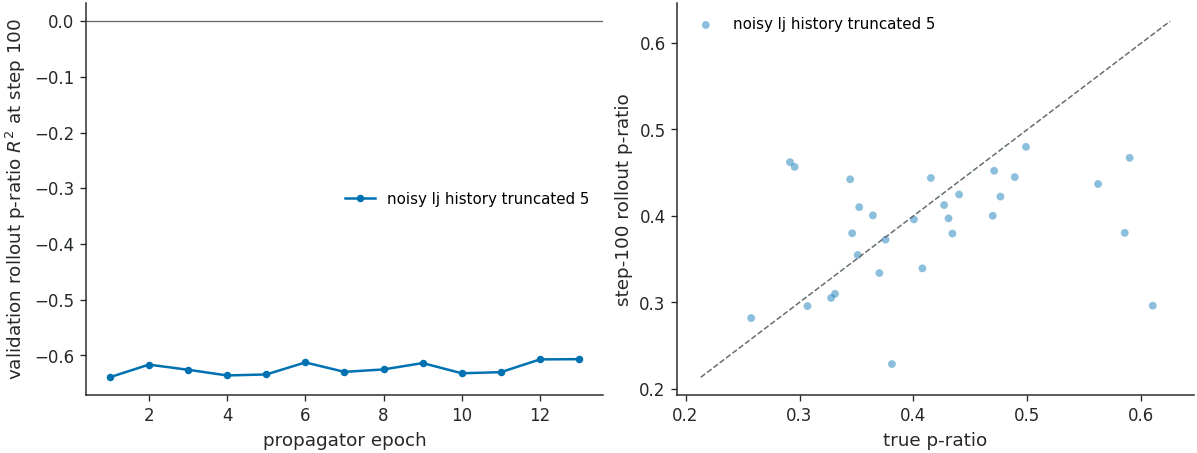

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10.0, 3.8), constrained_layout=True)
for experiment_name, result in results.items():
    history = result['dyn_history']
    column = 'val_rollout_source_lj_noisy_p_ratio_r2'
    rows = history[['epoch', column]].dropna()
    axes[0].plot(rows.epoch, rows[column], marker='o', markersize=3.5, lw=1.5, label=experiment_name.replace('_', ' '))
axes[0].axhline(0, color=PAPER_COLORS['slate'], lw=.8)
style_axes(axes[0], xlabel='propagator epoch', ylabel='validation rollout p-ratio $R^2$ at step 100', legend=True)

for experiment_name, result in results.items():
    rows = result['rollout_rows'].query("split == 'test' and source == 'lj_noisy' and rollout_steps == 100").dropna(subset=['true_p_ratio', 'pred_p_ratio'])
    axes[1].scatter(rows.true_p_ratio, rows.pred_p_ratio, s=22, alpha=.45, edgecolor='none', label=experiment_name.replace('_', ' '))
limits = np.r_[*[result['rollout_rows'].query("split == 'test' and source == 'lj_noisy' and rollout_steps == 100")[['true_p_ratio', 'pred_p_ratio']].to_numpy().ravel() for result in results.values()]]
limits = limits[np.isfinite(limits)]
if len(limits):
    lo, hi = limits.min(), limits.max(); pad = .04 * max(hi - lo, 1e-6)
    axes[1].plot([lo-pad, hi+pad], [lo-pad, hi+pad], '--', color=PAPER_COLORS['slate'], lw=.9)
style_axes(axes[1], xlabel='true p-ratio', ylabel='step-100 rollout p-ratio', legend=True)
plt.show()


## Latent correlation with final noisy-LJ p-ratio


In [ ]:
from lss.latent.experiment import ground_truth_p_ratio
from lss.latent.training import encode_frame_latent

import torch
# All propagators share the frozen AE; select the best propagator by validation rollout score.
validation_scores = {name: result['dyn_history']['val_rollout_source_lj_noisy_p_ratio_r2'].max(skipna=True) for name, result in results.items()}
best_experiment_name = max(validation_scores, key=validation_scores.get)
reference_result = results[best_experiment_name]
lj_test_sims = [sim for sim in reference_result['test_data'] if getattr(sim[0], 'source_name', None) == LJ_SOURCE][:30]
latent_rows = []
with torch.no_grad():
    for sim_index, sim in enumerate(lj_test_sims):
        target = ground_truth_p_ratio(sim, -1, dataset_name=LJ_SOURCE, cfg=reference_result['params'])
        frame_orders = list(range(0, len(sim), 4))
        if frame_orders[-1] != len(sim) - 1:
            frame_orders.append(len(sim) - 1)
        latents = np.stack([
            encode_frame_latent(reference_result['ae'], sim, frame, pos_dim=2,
                                node_feature_mode=reference_result['params']['node_feature_mode'],
                                normalizers=reference_result['normalizers'], device=DEVICE).detach().cpu().numpy().ravel()
            for frame in frame_orders
        ])
        time = np.asarray(frame_orders, dtype=float)
        for coordinate in range(latents.shape[1]):
            latent_rows.append({
                'trajectory': sim_index, 'coordinate': f'z{coordinate}', 'final_p_ratio': target,
                'initial': latents[0, coordinate], 'slope': np.polyfit(time, latents[:, coordinate], 1)[0],
            })
latent_summary = pd.DataFrame(latent_rows)
latent_correlation = latent_summary.groupby('coordinate', sort=False).apply(
    lambda group: pd.Series({
        'initial_pearson_r': np.corrcoef(group.initial, group.final_p_ratio)[0, 1],
        'full_trajectory_slope_pearson_r': np.corrcoef(group.slope, group.final_p_ratio)[0, 1],
        'n_heldout_trajectories': len(group),
    }), include_groups=False,
).reset_index()
display(latent_correlation.round(3))


,coordinate,initial_pearson_r,full_trajectory_slope_pearson_r,n_heldout_trajectories
0,z0,0.080,0.563,30.0
1,z1,0.079,-0.038,30.0


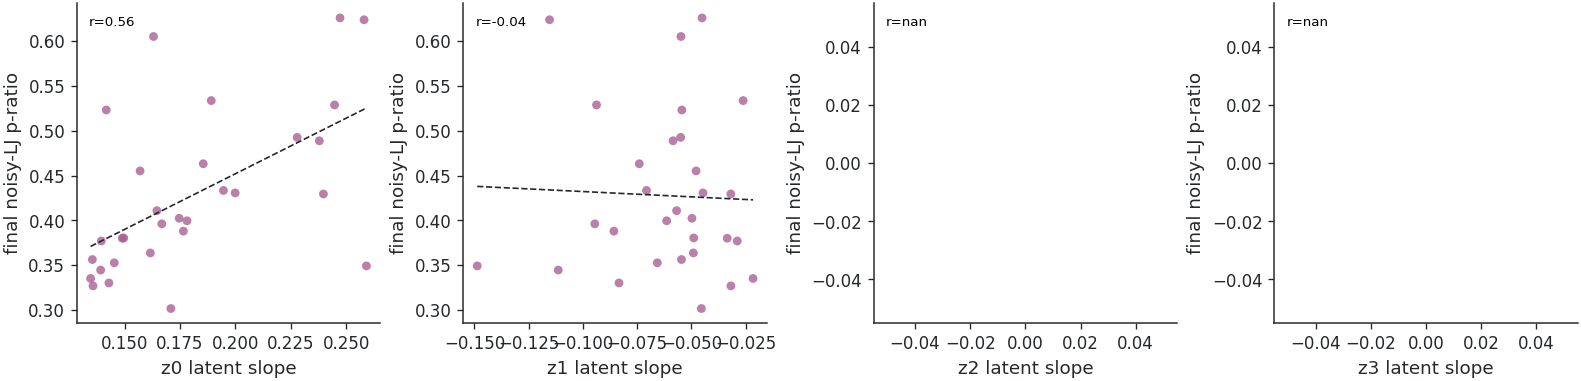

In [ ]:
n_coordinates = latent_summary.coordinate.nunique()
fig, axes = plt.subplots(1, n_coordinates, figsize=(3.3 * n_coordinates, 3.2), constrained_layout=True)
for coordinate, ax in enumerate(np.atleast_1d(axes)):
    rows = latent_summary.loc[latent_summary.coordinate.eq(f'z{coordinate}')].dropna(subset=['slope', 'final_p_ratio'])
    x = rows.slope.to_numpy(float)
    y = rows.final_p_ratio.to_numpy(float)
    pearson_r = np.corrcoef(x, y)[0, 1] if len(rows) > 1 and np.std(x) > 1e-12 and np.std(y) > 1e-12 else np.nan
    ax.scatter(x, y, s=28, alpha=.78, color=dataset_color(LJ_SOURCE), edgecolor='none')
    if len(rows) > 1 and np.std(x) > 1e-12:
        fit_slope, fit_intercept = np.polyfit(x, y, 1)
        xx = np.linspace(x.min(), x.max(), 100)
        ax.plot(xx, fit_slope * xx + fit_intercept, color=PAPER_COLORS['ink'], ls='--', lw=1.0)
    ax.text(.04, .96, f'r={pearson_r:.2f}', transform=ax.transAxes, ha='left', va='top', fontsize=8)
    style_axes(ax, xlabel=f'z{coordinate} latent slope', ylabel='final noisy-LJ p-ratio', legend=False)
plt.show()

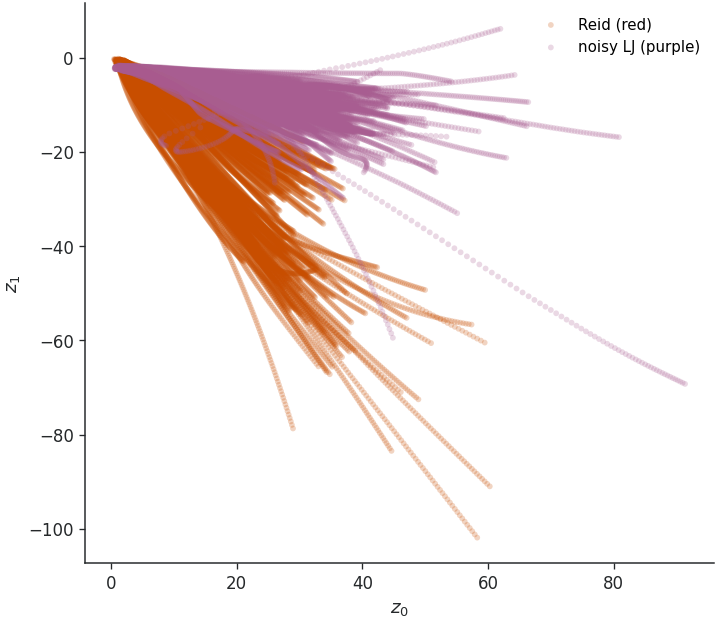

In [ ]:
from lss.latent.training import encode_frame_latent
# The first two coordinates of all frames from the frozen shared AE.
assert int(ae_training_result['params']['latent_dim']) >= 2
latent_plane_rows = []
all_ae_sims = [*ae_training_result['train_data'], *ae_training_result['val_data'], *ae_training_result['test_data']]
with torch.no_grad():
    for sim in all_ae_sims:
        source_key = str(getattr(sim[0], 'source_name', 'unknown'))
        for frame in range(len(sim)):
            z = encode_frame_latent(
                ae_training_result['ae'], sim, frame, pos_dim=2,
                node_feature_mode=ae_training_result['params']['node_feature_mode'],
                normalizers=ae_training_result['normalizers'], device=DEVICE,
            ).detach().cpu().numpy()
            latent_plane_rows.append({'source': source_key, 'z0': z[0], 'z1': z[1]})
latent_plane = pd.DataFrame(latent_plane_rows)

fig, ax = plt.subplots(figsize=(6.0, 5.2), constrained_layout=True)
legend_labels = {
    'reid': 'Reid (red)',
    'depablo_low_temp': 'de Pablo low-T (blue)',
    'depablo_mixed_temp': 'de Pablo mixed-T (green)',
    'lj_noisy': 'noisy LJ (purple)',
}
for source_key in DATASETS:
    rows = latent_plane.query('source == @source_key')
    ax.scatter(rows.z0, rows.z1, s=12, alpha=.24, color=dataset_color(source_key),
               edgecolor='none', label=legend_labels[source_key])
style_axes(ax, xlabel='$z_0$', ylabel='$z_1$', legend=True)
plt.show()
